# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.
Removendo duplicatas, restam **1'812** entradas.


In [56]:
%%html
<link rel="stylesheet" href="./style.css">

In [57]:
import import_ipynb  # noqa: F401
from treatment import (  # type: ignore
    f3_categorical_columns,
    f3_df,
    f3_numerical_columns,
)


In [58]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from kmodes.kprototypes import KPrototypes

from columns import target_columns
from data import dd_df, names_of_columns

In [59]:
def plot_boxplots_with_clusters_for_numerical_columns(
    data_frame: pd.DataFrame, cluster_column: str, numerical_columns: list[str]
):
    n = len(numerical_columns)

    fig, axes = plt.subplots(
        nrows=(n + 1) // 2, ncols=2, figsize=(14, 5 * ((n + 1) // 2))
    )

    axes = axes.flatten()

    for ax, col in zip(axes, numerical_columns):
        sns.boxplot(data=data_frame, x=cluster_column, y=col, ax=ax)

        ax.set_title(f"{col} por cluster")
        ax.set_xlabel("Cluster")
        ax.set_ylabel(names_of_columns[col])

    # remove eixos vazios
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()
    plt.show()

In [60]:
def plot_scatter_plot_with_clusters(data_frame: pd.DataFrame, x_axis: str, y_axis: str):
    sns.scatterplot(
        data=data_frame,
        x=x_axis,
        y=y_axis,
        hue="cluster",
        palette="tab10",
    )
    plt.title(f"Clusters: {names_of_columns[x_axis]} × {names_of_columns[y_axis]}")
    plt.show()


In [61]:
def plot_scatter_plot_pair_with_clusters(
    data_frame: pd.DataFrame, x_axis: str, y_axis: str
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # XY plot
    sns.scatterplot(
        data=data_frame,
        x=x_axis,
        y=y_axis,
        hue="cluster",
        palette="tab10",
        ax=axes[0],
    )
    axes[0].set_title(
        f"Clusters: {names_of_columns[x_axis]} × {names_of_columns[y_axis]}"
    )

    # YX plot
    sns.scatterplot(
        data=data_frame,
        x=y_axis,
        y=x_axis,
        hue="cluster",
        palette="tab10",
        ax=axes[1],
    )
    axes[1].set_title(
        f"Clusters: {names_of_columns[y_axis]} × {names_of_columns[x_axis]}"
    )

    plt.tight_layout()
    plt.show()


In [62]:
def plot_cluster_as_pillar_graph(data_frame: pd.DataFrame, categorical_column: str):
    proportions = (
        pd.crosstab(
            data_frame["cluster"], data_frame[categorical_column], normalize="index"
        )
        * 100
    )

    ax = proportions.plot(kind="bar", stacked=True, figsize=(10, 5))

    plt.title(f"{names_of_columns[categorical_column]} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Proporção (%)")
    plt.legend(
        title=names_of_columns[categorical_column],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## K-Prototypes


In [63]:
features = f3_categorical_columns + f3_numerical_columns
clustered_df_by_kp = f3_df[features].copy()

# K-Prototypes expects categorical columns as strings
for col in f3_categorical_columns:
    clustered_df_by_kp[col] = clustered_df_by_kp[col].astype(str)

# Identify indexes of categorical indexes
indexes_of_categorical_columns = [
    clustered_df_by_kp.columns.get_loc(col) for col in f3_categorical_columns
]

# Set parameters
k_prototypes_protocol = KPrototypes(n_clusters=3, random_state=42)

# Clustering
clusters = k_prototypes_protocol.fit_predict(
    clustered_df_by_kp.to_numpy(), categorical=indexes_of_categorical_columns
)

# Add column describing the cluster to the database
clustered_df_by_kp["cluster"] = clusters

# Add target variables back for cluster analysis
clustered_df_by_kp["paddy_yield"] = f3_df["paddy_yield"]
clustered_df_by_kp["trash"] = f3_df["trash"]

# Revert scaling
clustered_df_by_kp.hectares = dd_df["hectares"]
clustered_df_by_kp.paddy_yield = dd_df["paddy_yield"]
clustered_df_by_kp.trash = dd_df["trash"]


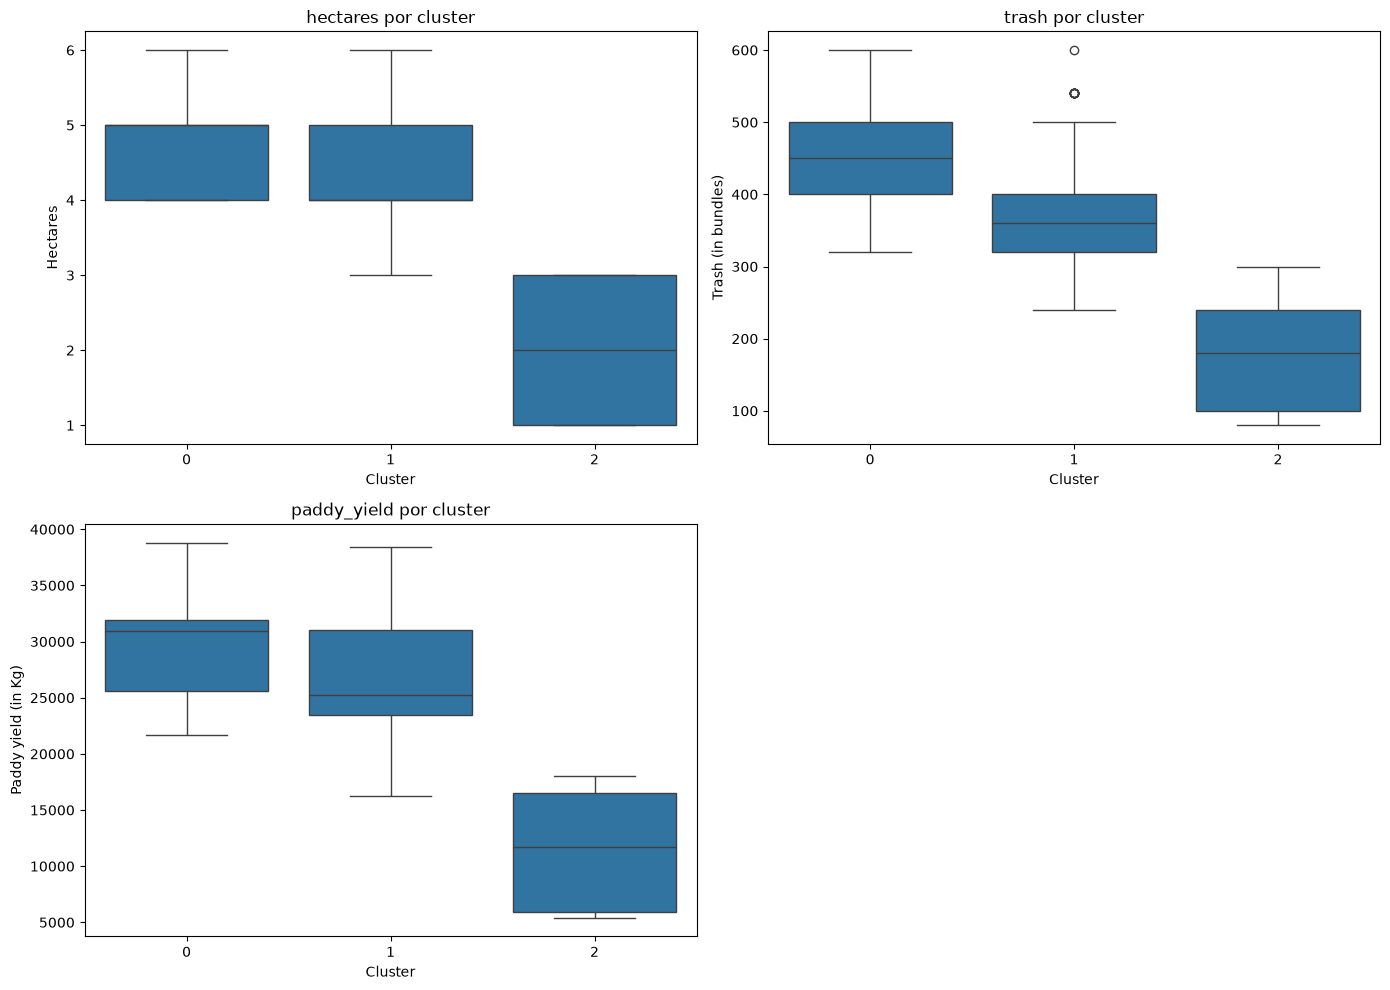

In [64]:
plot_boxplots_with_clusters_for_numerical_columns(
    data_frame=clustered_df_by_kp,
    cluster_column="cluster",
    numerical_columns=[*f3_numerical_columns, *target_columns],
)


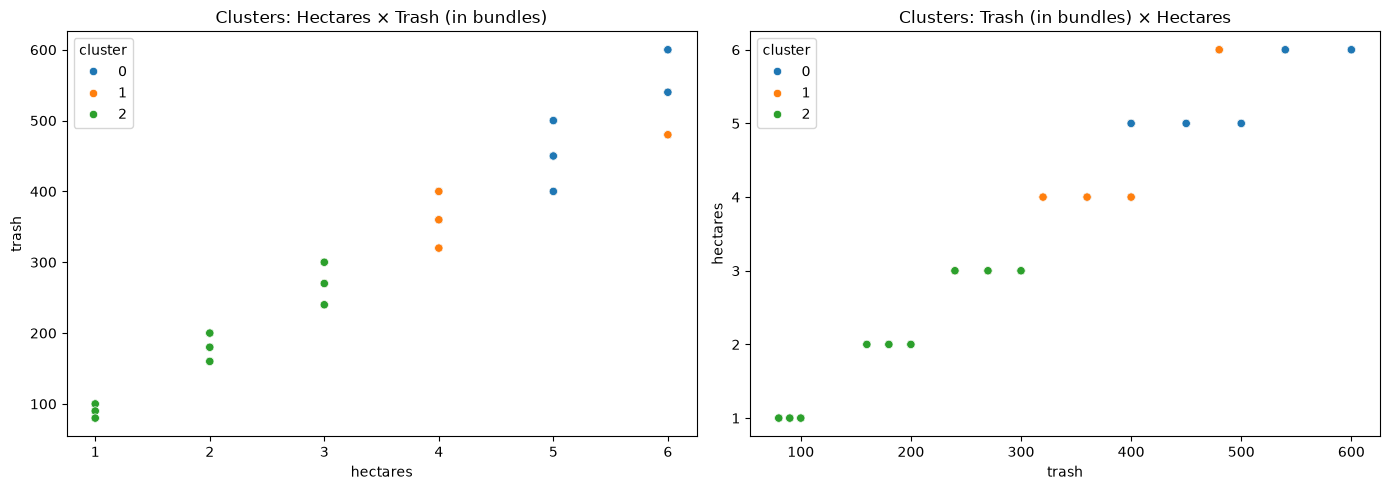

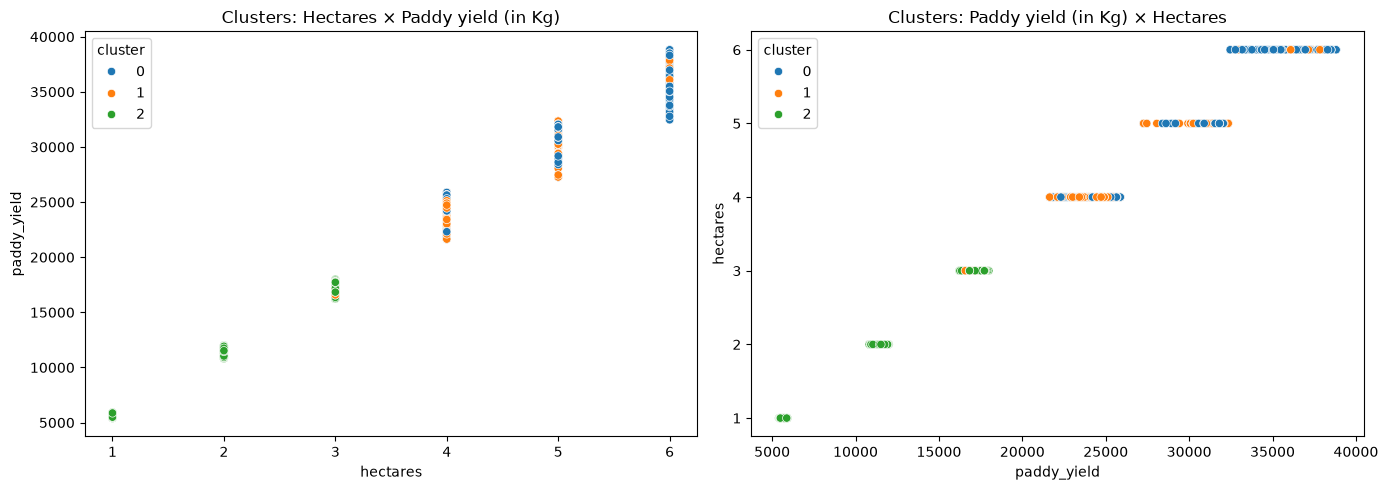

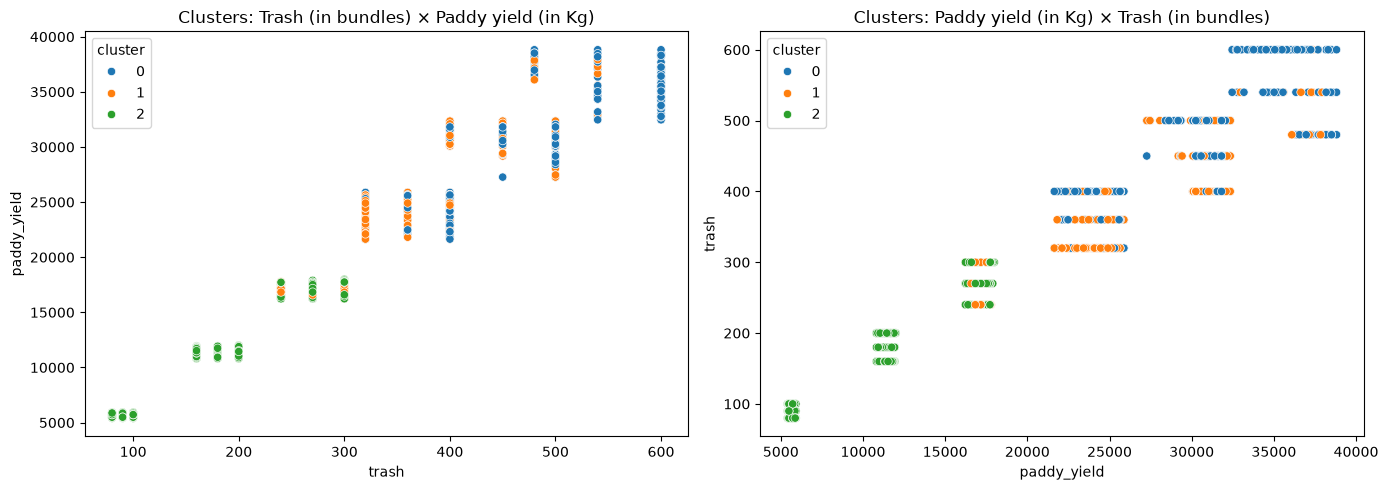

In [65]:
for x_axis, y_axis in combinations([*f3_numerical_columns, *target_columns], 2):
    plot_scatter_plot_pair_with_clusters(
        data_frame=clustered_df_by_kp,
        x_axis=x_axis,
        y_axis=y_axis,
    )

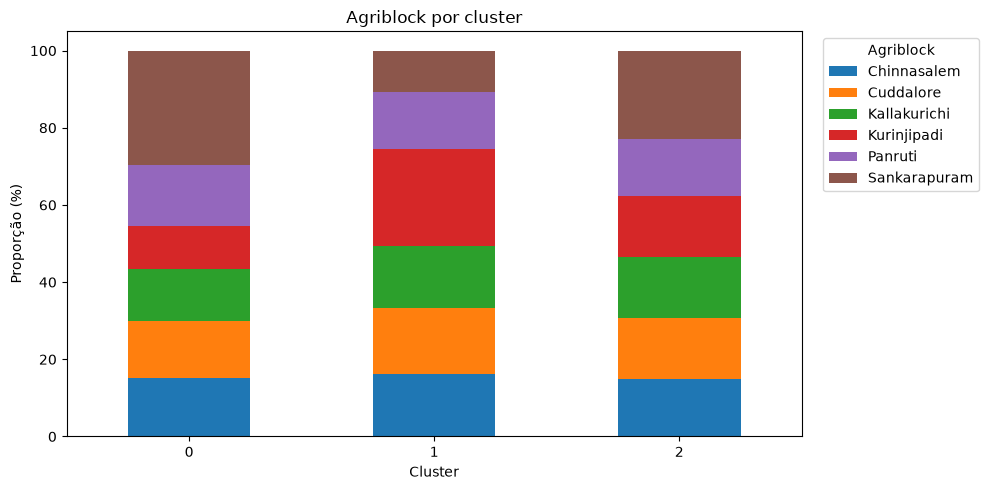

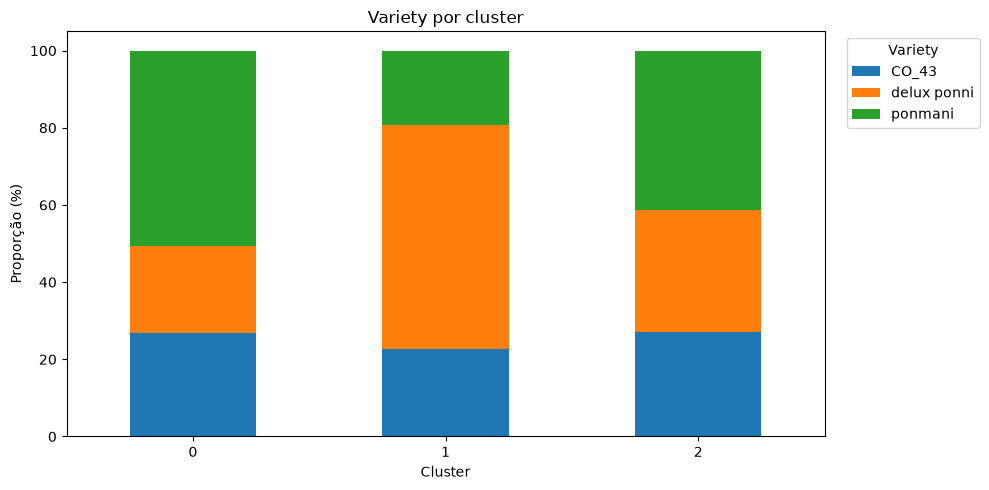

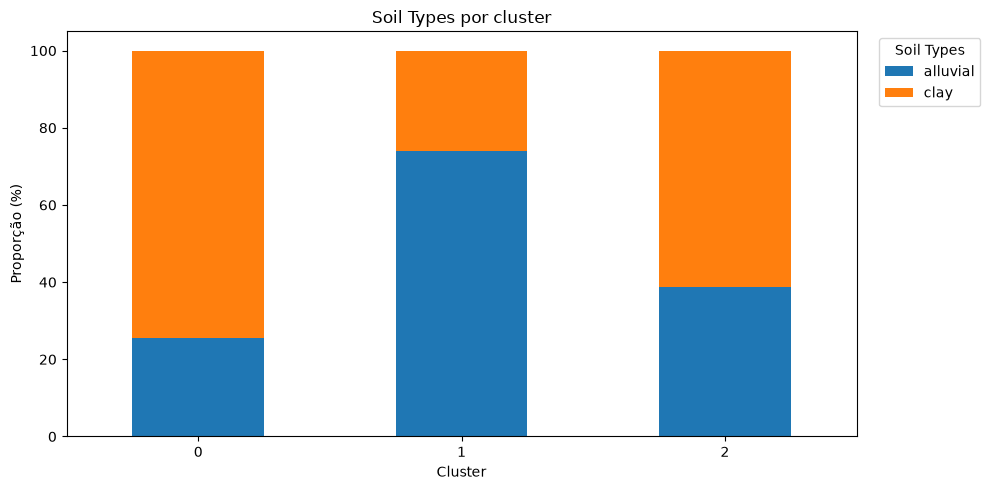

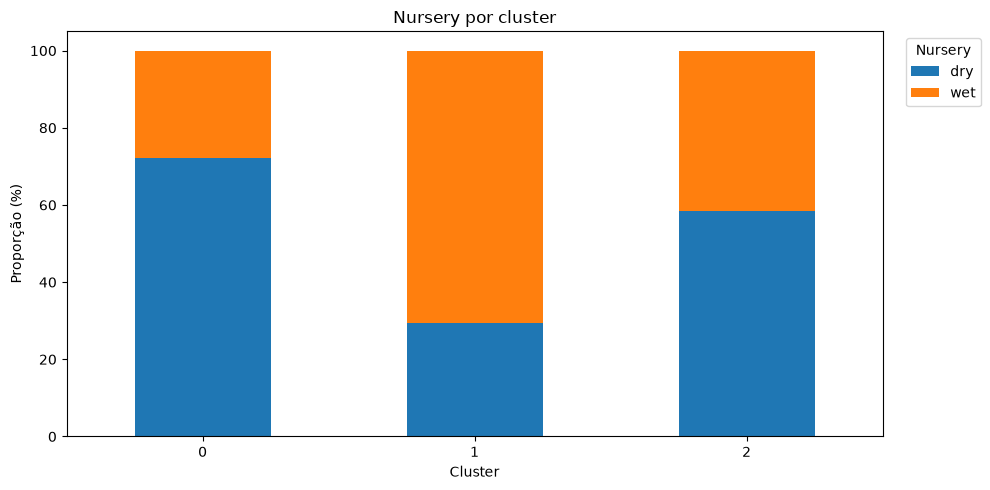

In [66]:
plot_cluster_as_pillar_graph(
    data_frame=clustered_df_by_kp, categorical_column="agriblock"
)

plot_cluster_as_pillar_graph(
    data_frame=clustered_df_by_kp, categorical_column="variety"
)

plot_cluster_as_pillar_graph(
    data_frame=clustered_df_by_kp, categorical_column="soil_type"
)

plot_cluster_as_pillar_graph(
    data_frame=clustered_df_by_kp, categorical_column="nursery"
)